# Testing Notebook

### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from network import Network
from test_utils import test_accuracy, show_ones

#### Testing Dataset

In [2]:
'''
Comment out the npz file that you don't want to use in testing.
'''
data = np.load('datasets/mnist.npz')
# data = np.load('datasets/fashion_mnist.npz')

x_train = data["x_train"] / 255 # NOTE normalizing the data here
y_train = data["y_train"]
x_test = data["x_test"] / 255
y_test = data["y_test"]

In [3]:
print('x_train/test format')
print(f'shape: {x_train.shape}')
print()
print('y_train/test format')
print(f'shape: {y_train.shape}')


x_train/test format
shape: (60000, 28, 28)

y_train/test format
shape: (60000,)


### Testing Stochastic Descent for One Network

In [5]:
ALPHA      = 0.5
MAX_STEPS  = 1000
BATCH_SIZE = 32

net = Network(shape=[784,128,64,10])
pre = test_accuracy(net, x_test=x_test, y_test=y_test)
net.descend_stoc(x_train=x_train,
             y_train=y_train,
             alpha=ALPHA,
             max_steps=MAX_STEPS,
             batch_size=BATCH_SIZE
             )
post = test_accuracy(net, x_test=x_test, y_test=y_test)


print( '----------------DESCENT SUMMARY----------------')
print(f'alpha = {ALPHA}, max_steps = {MAX_STEPS}, batch_size={BATCH_SIZE}')
print(f'pre-descent:{pre*100:.2f}')
print(f'post-descent:{post*100:.2f}')

----------------DESCENT SUMMARY----------------
alpha = 0.5, max_steps = 1000, batch_size=32
pre-descent:14.20
post-descent:92.80


In [10]:
net = Network(shape=[784,128,64,10])
net.descend_stoc(x_train, y_train, max_steps=3000)
print(f'accuracy: {test_accuracy(net)*100}%')

accuracy: 96.8%


### Visualizing Improvement Rate

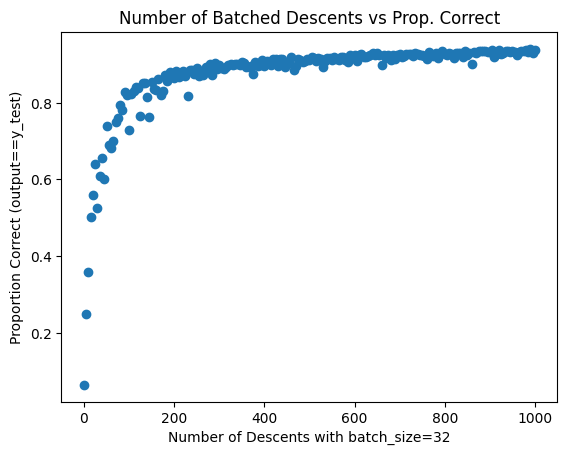

In [12]:
TOTAL_STEPS = 1000
TEST_EVERY  = 5
ALPHA       = 0.5
BATCH_SIZE  = 32
net = Network(shape=[784,128,64,10])

x = [i for i in range(0,TOTAL_STEPS+1, TEST_EVERY)] 
y = [test_accuracy(net, test_size=200)]

for i in range(TEST_EVERY, TOTAL_STEPS+1, TEST_EVERY):
    net.descend_stoc(x_train=x_train,y_train=y_train,alpha=ALPHA,max_steps=TEST_EVERY,batch_size=BATCH_SIZE)

    y.append(test_accuracy(net, test_size=10000))

plt.title('Number of Batched Descents vs Prop. Correct')
plt.xlabel(f'Number of Descents with batch_size={BATCH_SIZE}')
plt.ylabel(f'Proportion Correct (output==y_test)')
plt.scatter(x, y)
plt.show()

### Alpha Parameter Investigation


── alpha = 0.01 ──
  steps=   50  acc=10.6%
  steps=  100  acc=10.8%
  steps=  200  acc=16.0%
  steps=  400  acc=22.8%
  steps=  700  acc=48.8%
  steps= 1000  acc=64.8%

── alpha = 0.05 ──
  steps=   50  acc=16.4%
  steps=  100  acc=27.8%
  steps=  200  acc=64.4%
  steps=  400  acc=76.8%
  steps=  700  acc=85.2%
  steps= 1000  acc=87.2%

── alpha = 0.1 ──
  steps=   50  acc=21.6%
  steps=  100  acc=54.6%
  steps=  200  acc=75.4%
  steps=  400  acc=84.4%
  steps=  700  acc=90.0%
  steps= 1000  acc=91.0%

── alpha = 0.3 ──
  steps=   50  acc=67.4%
  steps=  100  acc=76.8%
  steps=  200  acc=85.8%
  steps=  400  acc=90.4%
  steps=  700  acc=90.2%
  steps= 1000  acc=91.4%

── alpha = 0.5 ──
  steps=   50  acc=80.0%
  steps=  100  acc=79.4%
  steps=  200  acc=86.4%
  steps=  400  acc=87.8%
  steps=  700  acc=90.8%
  steps= 1000  acc=94.6%

── alpha = 0.8 ──
  steps=   50  acc=77.8%
  steps=  100  acc=78.0%
  steps=  200  acc=90.2%
  steps=  400  acc=93.0%
  steps=  700  acc=92.6%
  steps= 

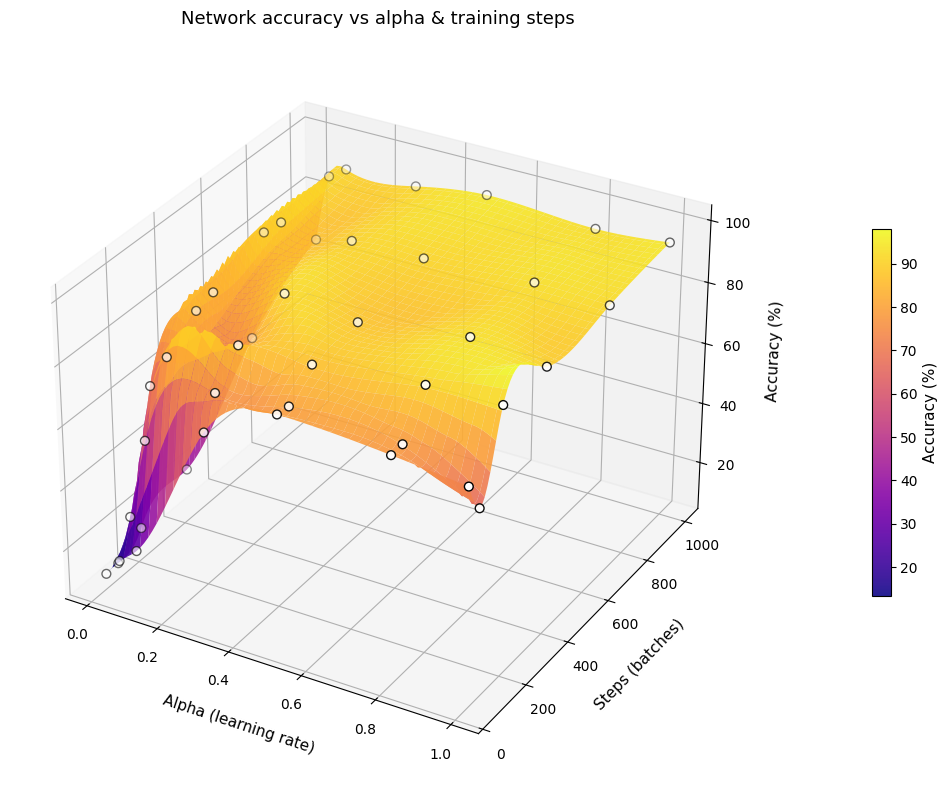

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from network import Network
import copy

# ── Config ─────────────────────────────────────────────────────────────────────
ALPHAS      = [0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 1.0]
CHECKPOINTS = [50, 100, 200, 400, 700, 1000]
BATCH_SIZE  = 32
TEST_SIZE   = 500
SHAPE       = [784, 128, 64, 10]

# ── Shared starting weights so every alpha begins from the same point ──────────
default_net = Network(shape=SHAPE)

# ── Run experiment ─────────────────────────────────────────────────────────────
results = {}  # { alpha: { steps: accuracy } }

for alpha in ALPHAS:
    print(f"\n── alpha = {alpha} ──")

    # Fresh network with identical starting weights/biases
    net = Network(shape=SHAPE, random_wb=False)
    net.weights = copy.deepcopy(default_net.weights)
    net.biases  = copy.deepcopy(default_net.biases)

    results[alpha] = {}
    prev_steps = 0

    for steps in CHECKPOINTS:
        delta = steps - prev_steps
        net.descend_stoc(
            x_train=x_train,
            y_train=y_train,
            alpha=alpha,
            max_steps=delta,
            batch_size=BATCH_SIZE
        )
        acc = test_accuracy(net, x_test=x_test, y_test=y_test, test_size=TEST_SIZE)
        results[alpha][steps] = acc
        prev_steps = steps
        print(f"  steps={steps:>5}  acc={acc*100:.1f}%")

# ── Build flat arrays for plotting ─────────────────────────────────────────────
plot_alpha = []
plot_steps = []
plot_acc   = []

for alpha in ALPHAS:
    for steps in CHECKPOINTS:
        plot_alpha.append(alpha)
        plot_steps.append(steps)
        plot_acc.append(results[alpha][steps] * 100)

plot_alpha = np.array(plot_alpha)
plot_steps = np.array(plot_steps)
plot_acc   = np.array(plot_acc)

# ── Interpolate surface ────────────────────────────────────────────────────────
alpha_grid = np.linspace(plot_alpha.min(), plot_alpha.max(), 80)
steps_grid = np.linspace(plot_steps.min(), plot_steps.max(), 80)
A, S = np.meshgrid(alpha_grid, steps_grid)

Z = griddata(
    points=(plot_alpha, plot_steps),
    values=plot_acc,
    xi=(A, S),
    method='cubic'
)

# Clamp to valid accuracy range in case cubic overshoots
Z = np.clip(Z, 0, 100)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, S, Z, cmap='plasma', edgecolor='none', alpha=0.9)

# Raw measurement points on top
ax.scatter(plot_alpha, plot_steps, plot_acc,
           color='white', edgecolors='black', s=40, zorder=5)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Accuracy (%)', fontsize=11)

ax.set_xlabel('Alpha (learning rate)', fontsize=11, labelpad=10)
ax.set_ylabel('Steps (batches)',        fontsize=11, labelpad=10)
ax.set_zlabel('Accuracy (%)',           fontsize=11, labelpad=10)
ax.set_title('Network accuracy vs alpha & training steps', fontsize=13, pad=15)

plt.tight_layout()
plt.show()

### Pick the Best of 20

In [ ]:
from test_utils import best_of, test_accuracy

net = best_of(5, shape=[784, 128, 64, 10], xt=x_train, yt=y_train, alpha=0.5, max_steps=500)

print(test_accuracy(net))

0.082


In [3]:
net = Network(shape=[784, 128, 64, 10])
net.descend_stoc(x_train=x_train, y_train=y_train, alpha=0.5, max_steps=1000, batch_size=32)

print(test_accuracy(net))

0.946


# Future Stuff

### Standardizing The Module

Q: how do we standardize the x_train, y_train inputs  
Q: what do we do about the output one hot encoding (temp function right now in .get_descent method)  
Q: setting up epochs  

Major Question: Do we want things like epoch optimization to all be parts of the network class, or do have other parent classes/functions/etc. that use this simple network. Descent is already part of the class so I think it makes sense to do that.